In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

P = set_P()

betas = collect(0.0:1.0:20.0)
mus = collect(-1.0:0.025:1.0)

Mpemba_data1 = zeros(length(mus), length(betas))
Mpemba_data2 = zeros(length(mus), length(betas))
@showprogress for (j,beta) in enumerate(betas)
    P.β_L = beta
    P.β_R = beta
    for (i,mu) in enumerate(mus)
        P.μ_L = mu
        P.μ_R = mu
        pf, pinf = calculate_mpemba(P, 20.0)
        tracedist = abs(pf - pinf)
        Mpemba_data1[i,j] = tracedist
        if (pf < 0.0) || (pf > 1.0)
            tracedist = NaN
        end
        Mpemba_data2[i,j] = tracedist
    end
end




Mpemba_plot1 = heatmap(betas, mus, Mpemba_data1,  ylabel="\$\\mu / D\$",xlabel="\$\\beta D\$",title="\$|p_f - p(\\infty)|\$",
 aspect_ratio=2.62(length(mus)/length(betas)), size=(600,600), dpi=400)
Mpemba_plot2 = heatmap(betas, mus, Mpemba_data2,  ylabel="\$\\mu / D\$",xlabel="\$\\beta D\$",title="\$|p_f - p(\\infty)|\$",
 aspect_ratio=2.62(length(mus)/length(betas)), size=(600,600), dpi=400)
display(Mpemba_plot1)
display(Mpemba_plot2)

savefig(Mpemba_plot1, "Mpemba_heatmap1.png")
savefig(Mpemba_plot2, "Mpemba_heatmap2.png")

P = set_P()
#mu = 0.01
beta = 20.0
gamma = 0.05
N = 20

P.spec_fun = "ellipse"
P.T = 20.0
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta

mus = collect(-0.5:0.02:0.5)
#inverseFT_spectral_function(P)
#calculate_RHP(P, plotting=true)
#mpemba = zeros(length(mus))
meas = zeros(length(mus))
meas_tot = zeros(length(mus))
@showprogress for (i,mu) in enumerate(mus)
    P.μ_L = mu
    P.μ_R = mu

    #pf, pinf = calculate_Mpemba(P, 20.0)
    #mpemba[i] = abs(pf - pinf)
    data, _ = calculate_oCP(P)
    meas[i] = maximum(data)
    meas_tot[i] = sum(data)
end

p = plot(mus, meas, xlabel="\$\\frac{1}{2}\\int^{\\infty}_{0} dt \\int^{\\t}_{0} ds||\\Lambda(t,0) - \\Phi(t,s)\\Lambda(s,0)||_1\$", label="Mpemba", legend=:topleft, lw=2, dpi=400)
plot!(twinx(p), mus, meas_tot, ylabel="\$ \\max_{t>s} \\frac{1}{2}||\\Lambda(t,0) - \\Phi(t,s)\\Lambda(s,0)||_1 \$", label="Measure", legend=:topright, c=:red, lw=2)
#plot!(twinx(p), mus)
display(p)


Progress: 100%|█████████████████████████████████████████| Time: 0:19:21
Progress: 100%|█████████████████████████████████████████| Time: 0:16:40
Progress: 100%|█████████████████████████████████████████| Time: 0:16:26
Progress: 100%|█████████████████████████████████████████| Time: 0:18:23
Progress: 100%|█████████████████████████████████████████| Time: 0:17:10
Progress: 100%|█████████████████████████████████████████| Time: 0:16:01
Progress:  90%|██████████████████████████████████████   |  ETA: 0:01:30Excessive output truncated after 524435 bytes.

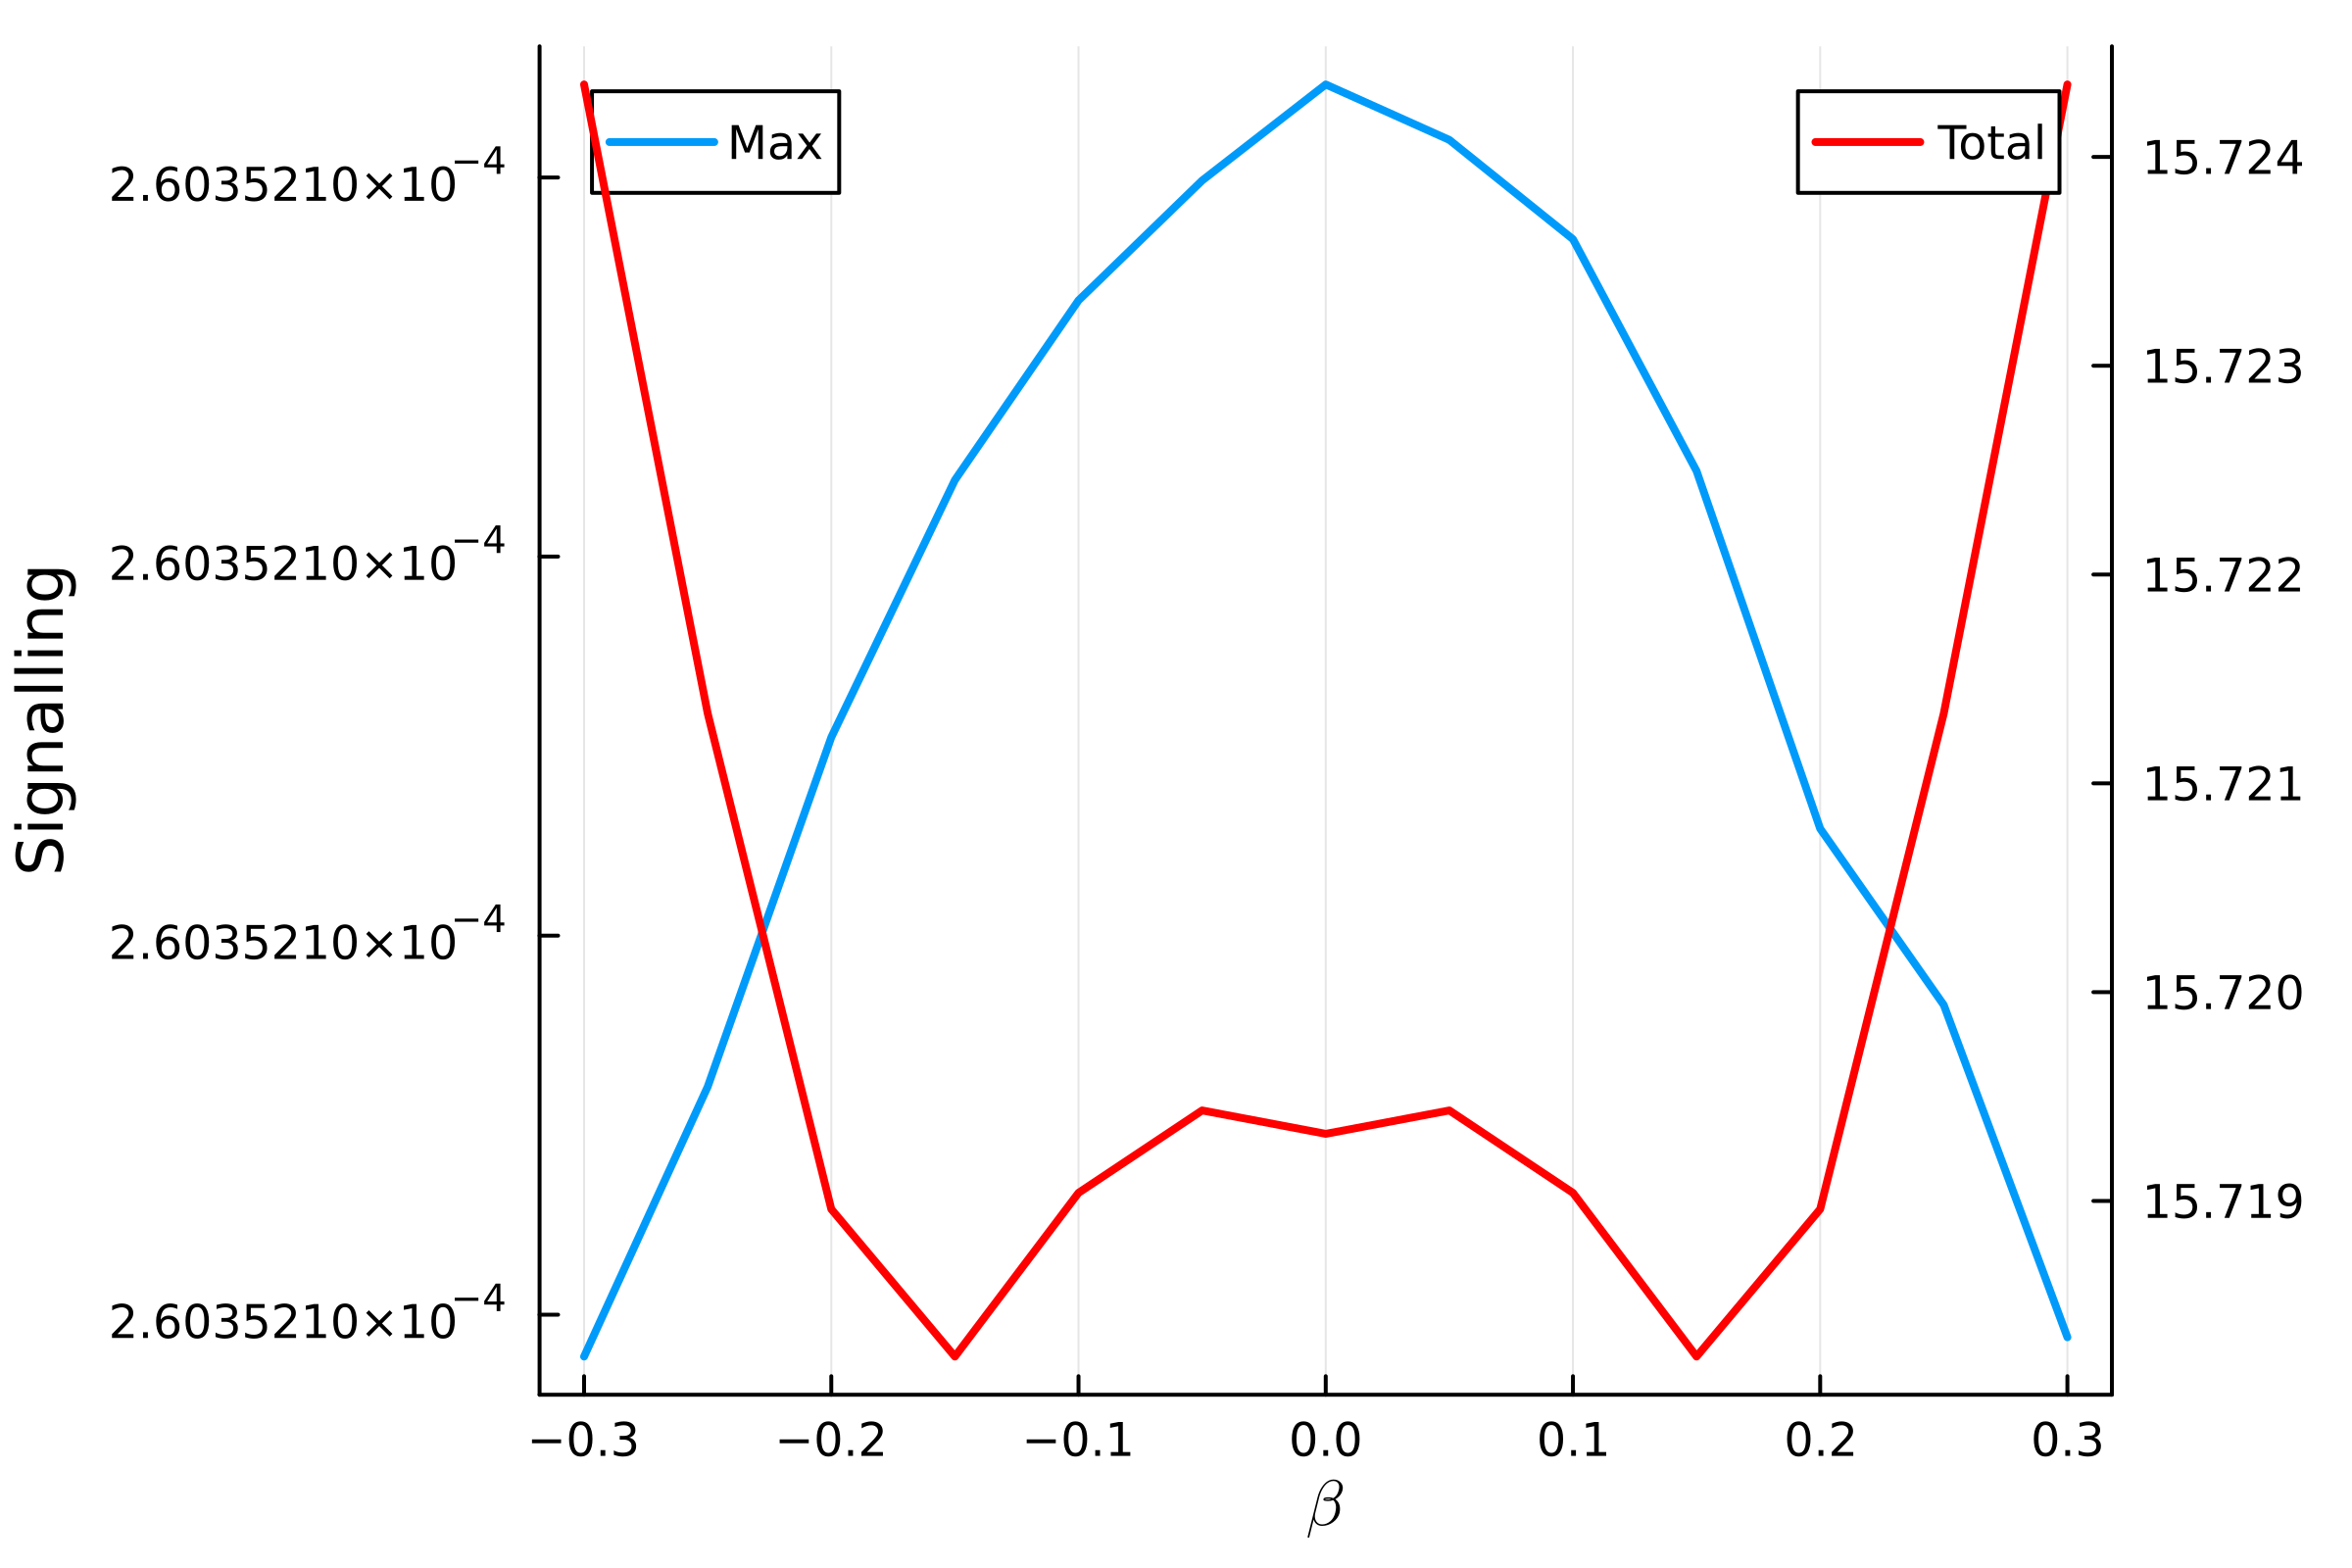

In [2]:
P = set_P()
#mu = 0.0
beta = 20.0
gamma = 0.01
T = 60.0
N = Int(T) 

P.spec_fun = "ellipse"
P.T = T
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
#P.μ_L = mu
#P.μ_R = mu

mus = collect(-0.3:0.05:0.3)
meas = zeros(length(mus))
meas_tot = zeros(length(mus))
@showprogress for (i,mu) in enumerate(mus)
    P.μ_L = mu
    P.μ_R = mu

    #pf, pinf = calculate_Mpemba(P, 20.0)
    #mpemba[i] = abs(pf - pinf)
    tracedist, times = calculate_Signalling(P)
    meas[i] = maximum(tracedist)
    meas_tot[i] = sum(tracedist)
end

p = plot(mus, meas, xlabel="\$\\beta\$", ylabel="Signalling", label="Max", legend=:topleft, lw=2, dpi=400)
plot!(twinx(p), mus, meas_tot, label="Total", legend=:topright, c=:red, lw=2)
#plot!(twinx(p), mus)
display(p)


#mem_time, mem_idx = calculate_TDFP(P, plotting=true)
#tracedist, times = calculate_Signalling(P, plotting=true)


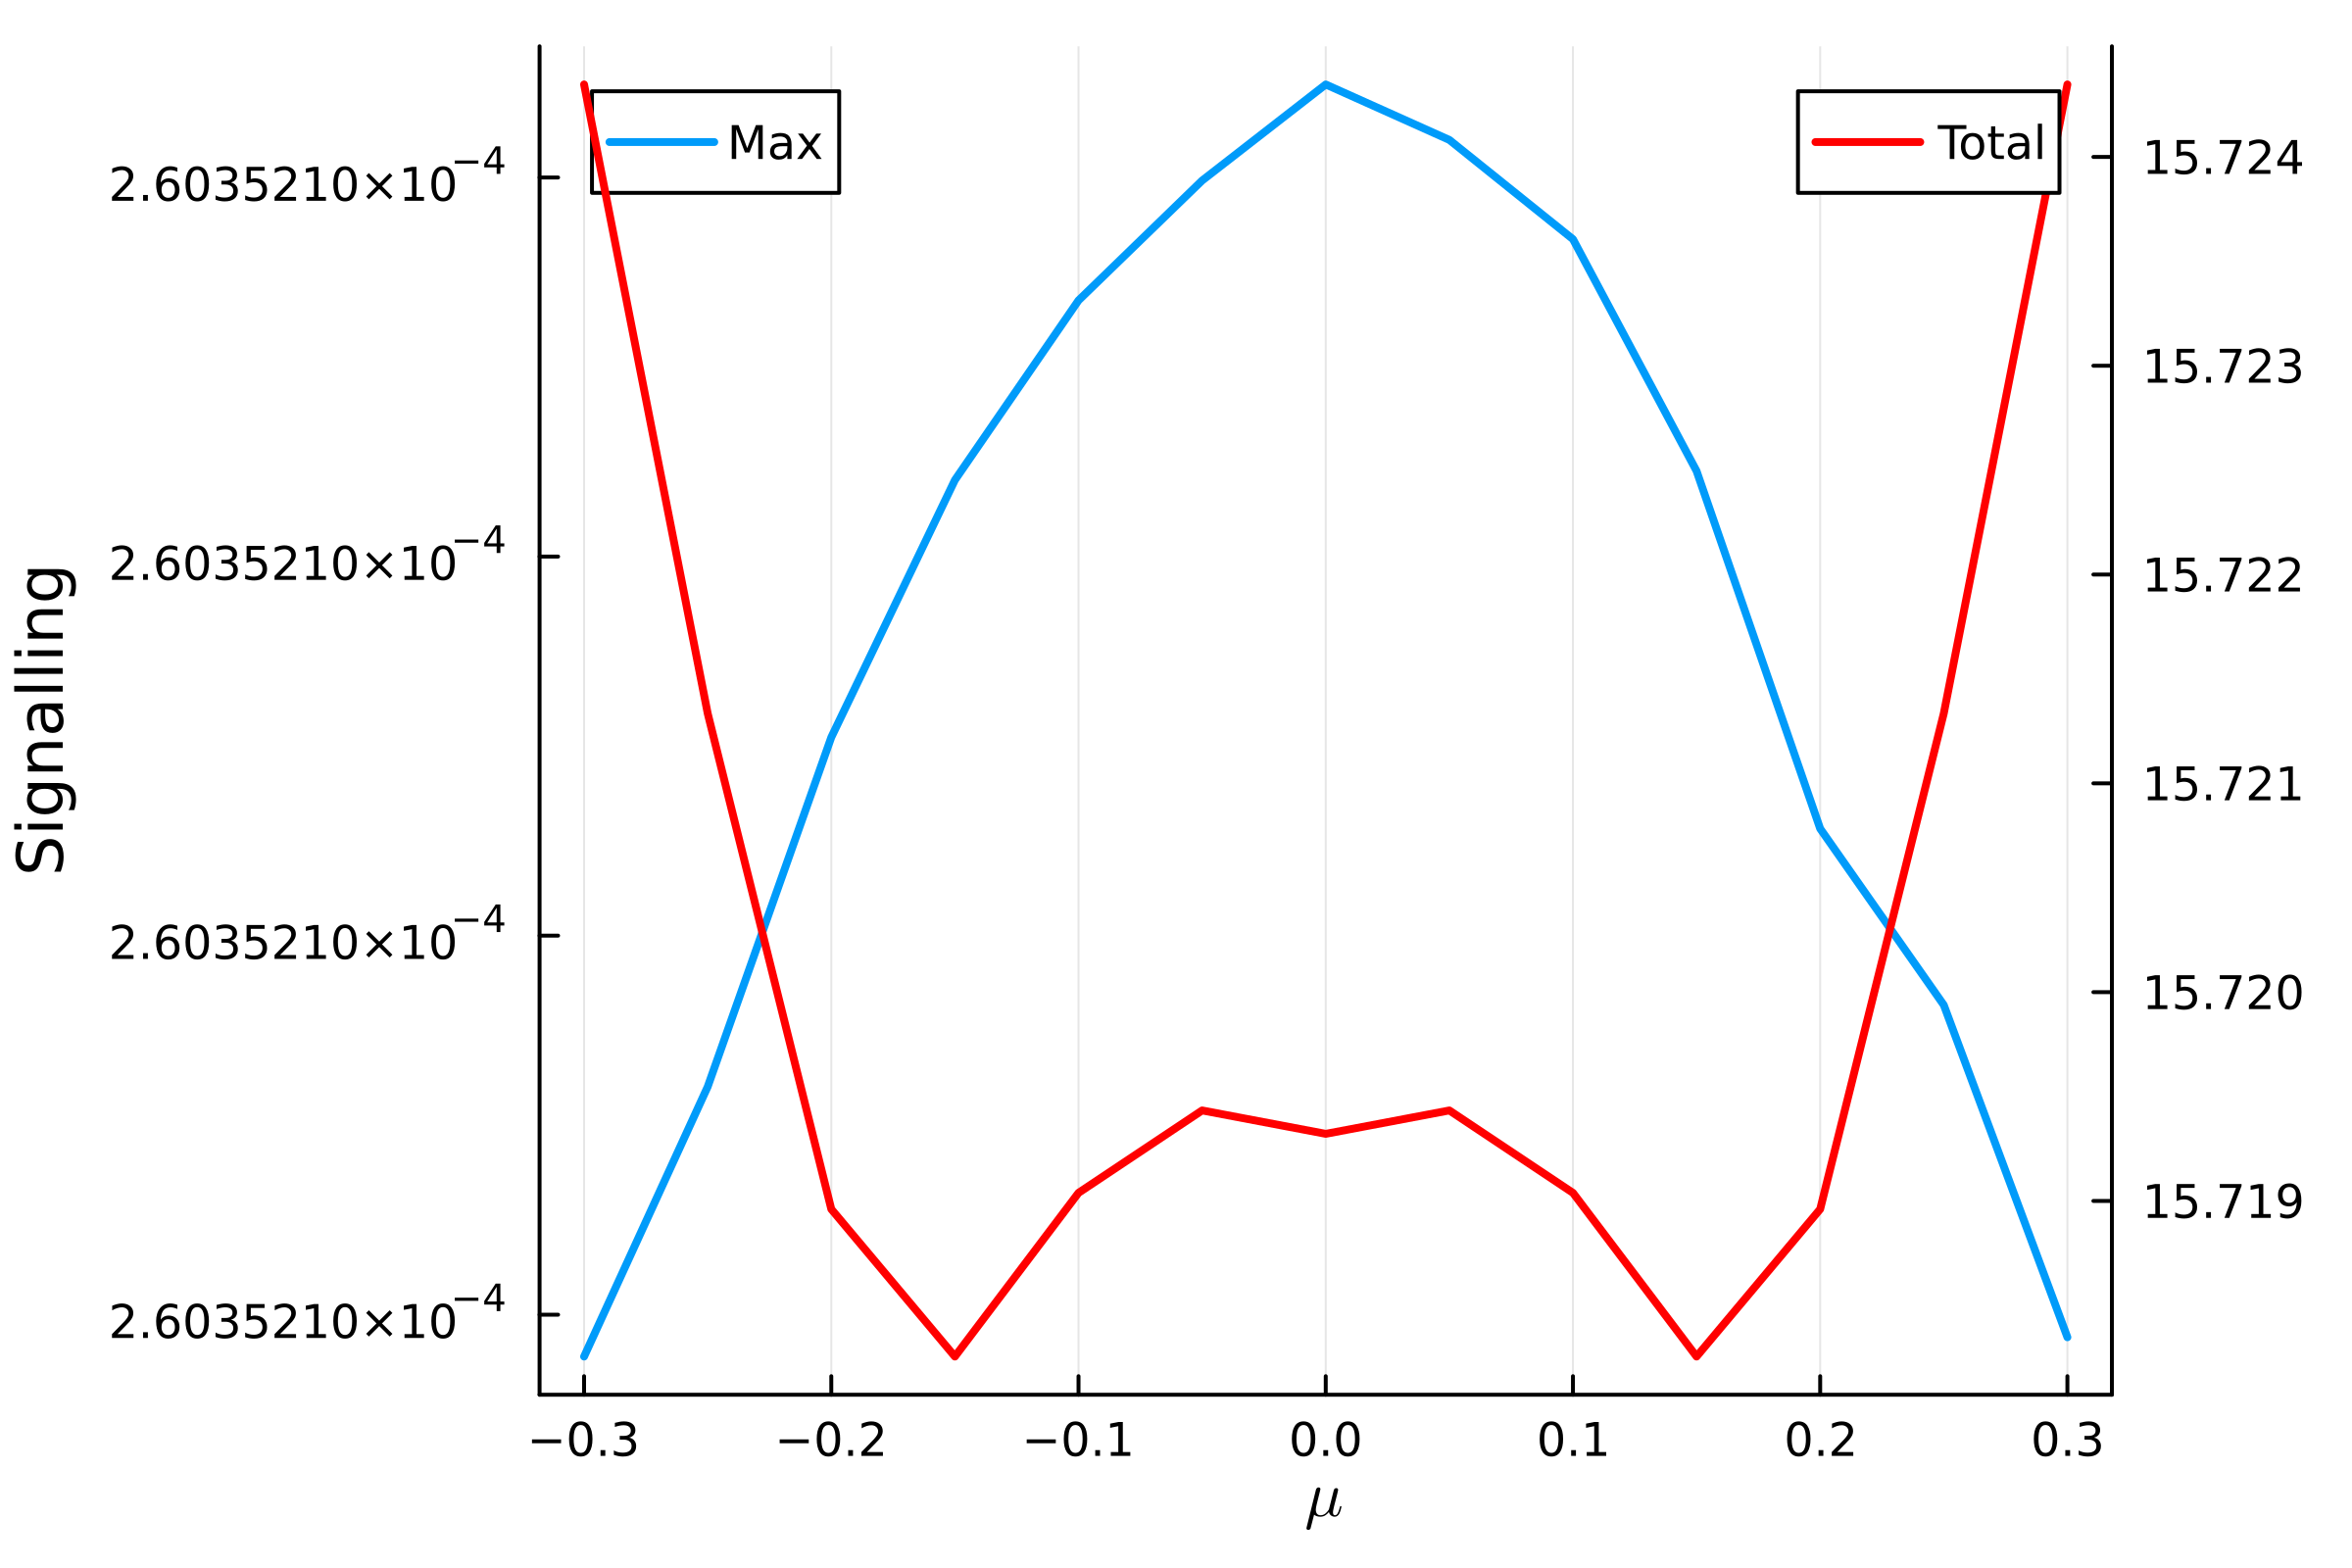

In [6]:
p = plot(mus, meas, xlabel="\$\\mu\$", ylabel="Signalling", label="Max", legend=:topleft, lw=2, dpi=400)
plot!(twinx(p), mus, meas_tot, label="Total", legend=:topright, c=:red, lw=2)
#plot!(twinx(p), mus)
display(p)

In [4]:
data = sum(tracedist, dims=2) * (P.dt)
p1 = plot(times, data, xlabel="\$t-s\$", ylabel="Integral over \$s\$", label="", lw=2, dpi=400) 

data = transpose(sum(tracedist, dims=1)) * (P.dt)
p2 = plot(times, data, xlabel="\$s\$", ylabel="Integral over \$t-s\$", label="", lw=2, dpi=400) 

p = plot(p1, p2, layout=(2,1), size=(800,600))


UndefVarError: UndefVarError: `tracedist` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [5]:
idxs = argmax(tracedist)
idx1, idx2 = Tuple(idxs)

data = tracedist[idx1, :]
p1 = plot(times, data, xlabel="\$\\tau\$", ylabel="\$\\mathcal{D}(t,s)\$", label="\$t-s = $(round(times[idx1], digits=1))\$", lw=2, dpi=800, legend=:bottomright) 

data = tracedist[:, idx2]
plot!(p1, times, data, label="\$s = $(round(times[idx2], digits=1))\$", lw=2) 
display(p1)


UndefVarError: UndefVarError: `tracedist` not defined in `Main`
Suggestion: check for spelling errors or missing imports.